# Benchmark ASPIRE LES and FLORIS CC on cumulative energy & cumulative energy wake loss

In this notebook, we will demonstrate a comparison of Whiffles ASPIRE LES and FLORIS CC models against the measured baseline SCADA data from the Smarteole dataset. We benchmark the models using two metrics: wind-farm-wide cumulative energy production (MWh) and the wind-farm-wide cumulative wake loss (%). The latter metric is equivalent to the wake loss and wake-loss error metrics, 'L' and 'epsilon', from Orsteds large-scale benchmarking paper, described in the article "Large-scale benchmarking of wake models for offshore wind farms" by Nygaard et al. While this method benchmarks ASPIRE LES and FLORIS against SCADA, it may also be used to benchmark FLORIS against LES, purely FLORIS against SCADA, or purely LES against SCADA.


**The general approach followed in this notebook is**:
1. Load the cleaned-up SCADA data timeseries.
2. Generate an equivalent FLORIS data timeseries based on SCADA's freestream wind speeds and wind directions. We do this using a precalculated table of solutions and linear interpolation, but for simple wind farms without neighbors users may also directly use the FLORIS timeseries calculation mode instead.* 
3. Generate an equivalent LES data timeseries. There are various decisions one can make here. 

    a. In this example, we simulated the ASPIRE LES code for the exact same time window as the SCADA data. Since ASPIRE LES uses ERA5, it is highly likely that measured (SCADA) and simulated (LES) freestream conditions are very comparable. Thus, one may not need to apply any modifications and can just directly use the LES timeseries.

    b. Alternatively, one may want to force a perfect agreement between the LES-simulated and SCADA-measured timeseries. One can achieve this by binning the LES simulation output into a grid of wind directions and wind speeds, similar to a `df_fm_approx` table for FLORIS. Then, using linear interpolation one can turn this into a LES timeseries where the freestream wind conditions and wind speeds are those measured by SCADA.

    We explore both options in the notebook below.
4. Once all dataframe timeseries are available (SCADA, LES, FLORIS), we must match the missing outliers. Thus, we copy over any NaNs in the SCADA to the LES/FLORIS predictions, and vice versa. This ensures we compare apples to apples.
5. Finally, we can calculate the relevant metrics: cumulative energy production, and relative wake loss. We do this both for each individual turbine and the wind farm as a whole.

Note that the dataset in this example only contains 3 months of data. Hence, the final numbers cannot be interpreted as "annual energy production" metrics, but rather only represent the cumulative production for the time period of the data.

*(*if you have neighboring wind farms, then the measured freestream conditions from the SCADA are the wind speeds measured by the turbines of your own wind farm, not necessarily the most upstream turbine of all the machines simulated in case of neighbors. The recommended practice here would then be: 1. Generate a high-resolution grid of FLORIS solutions while modeling all neighbors, 2. Overwrite the 'ws' column in this `df_fm_approx` file with the wind speeds measured by the upstream turbines of your internal wind farm using the `dfm.set_ws_by_upstream_turbs()` function, and 3. interpolate these solutions back to a new regular, monotonic grid.)*


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from flasc.analysis import energy_ratio as er
from flasc.analysis.analysis_input import AnalysisInput
from flasc.data_processing import dataframe_manipulations as dfm
from flasc.data_processing import time_operations as tops
from flasc.data_processing.timeseries_to_grid_solutions import bin_timeseries_to_grid

from flasc.utilities import floris_tools as ftools
from flasc.utilities.utilities_examples import load_floris_smarteole as load_floris

from flasc.analysis.cumulative_production_analysis import compare_cumulative_production_and_relative_wake_loss

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Step 0: Specify user settings and load FLORIS
Specify turbines we want to use (for reference conditions and for benchmarking). We also load a FLORIS model for the wind farm at hand and determine which turbines are upstream for every wind direction.

In [12]:
# Specify which turbines to include/exclude. Since it's all baseline operation, we use all turbines.
include_turbs = [0, 1, 2, 3, 4, 5, 6]
exclude_turbs = []

# Load FLORIS model of site
fm, turbine_weights = load_floris()

# Use FLORIS to identify upstream / unwaked turbines for each direction
df_upstream = ftools.get_upstream_turbs_floris(fm)

# Step 1: Load processed SCADA data

Load the processed SCADA data and assign reference wind directions and wind speeds by the upstream turbines

In [13]:
def load_data():
    root_path = Path.cwd()
    f = root_path / "postprocessed" / "df_scada_data_60s_filtered_and_northing_calibrated.pkl"
    df_scada = pd.read_pickle(f)

    return df_scada

# Load the data
df_scada = load_data()

# Calculate some helper variables
n_turbs = dfm.get_num_turbines(df_scada)
pow_cols = [f"pow_{ti:03d}" for ti in range(n_turbs)]
print(f"Number of turbines in dataset: {n_turbs}.")

# The SCADA data set contains alternating 1-hour periods with baseline or wake steering control.
# For these examples, we'll limit the data to baseline operation. 
df_scada = df_scada[df_scada.control_mode == "baseline"].reset_index(drop=True)

# Set the wind direction as the average of all turbine averages
df_scada = dfm.set_wd_by_turbines(df_scada, include_turbs)

# Set the wind speed to be the average of all upstream turbines
# (turbines not in a wake in a given direction)
# Except for SMV5
df_scada = dfm.set_ws_by_upstream_turbines(df_scada, df_upstream, exclude_turbs=exclude_turbs)

# Scale power columns in SCADA from kW to W to match the FLORIS and LES units
df_scada[pow_cols] = df_scada[pow_cols] * 1.0e3

# Print information to console
print(df_scada)

Number of turbines in dataset: 7.
FlascDataFrame in FLASC format
                     time      pow_000    pow_001    pow_002   pow_003  \
0     2020-02-17 16:30:00  2023747.000  2045377.0  2031725.0       NaN   
1     2020-02-17 16:31:00  1959036.000  2050573.0  2034891.0       NaN   
2     2020-02-17 16:32:00  2053658.875  2032191.0  2011871.0       NaN   
3     2020-02-17 16:33:00  2044297.000  2060478.0  1995058.0       NaN   
4     2020-02-17 16:34:00  2058281.000  2042703.0  2031724.0       NaN   
...                   ...          ...        ...        ...       ...   
81949 2020-05-24 22:56:00   179934.000   157004.0   192215.0  188413.0   
81950 2020-05-24 22:57:00   181415.000   176386.0   191846.0  198540.0   
81951 2020-05-24 22:58:00   187748.000   181809.0   183803.0  179539.0   
81952 2020-05-24 22:59:00   175552.000   176250.0   183923.0  152393.0   
81953 2020-05-24 23:00:00   169325.000   179944.0   173608.0  136597.0   

         pow_004    pow_005    pow_006  ws_000

# Step 2: Calculate FLORIS model predictions for the SCADA dataset
We first calculate the FLORIS model predictions for the SCADA dataset using our precalculated grid of FLORIS solutions. We only look at the Cumulative Curl (CC) model here, but can readily also use other wake models.

In [4]:
# Grab a FLORIS solution and turn it into a timeseries
wake_model = "cc"
fn = Path.cwd() / "precalculated_floris_solutions" / "df_fi_approx_{:s}.ftr".format(wake_model)
if fn.is_file():
    df_fm_approx = pd.read_feather(fn)
else:
    raise UserWarning(
        "Please run '01_precalculate_floris_solutions.ipynb' "
        "for the appropriate wake models first."
    )

df_floris_timeseries = ftools.interpolate_floris_from_df_approx(
    df=df_scada, df_approx=df_fm_approx, method="linear", verbose=True
)
print(df_floris_timeseries)

2026-03-04 12:02:26 Identified the following grid type: 3d.


2026-03-04 12:02:26 Warning: the values in df[ws] exceed the range in the precalculated solutions df_fi_approx[ws].
2026-03-04 12:02:26    minimum/maximum value in df:        (0.250, 19.557)
2026-03-04 12:02:26    minimum/maximum value in df:        (0.250, 19.557)
2026-03-04 12:02:26    minimum/maximum value in df_approx: (1.000, 30.000)
2026-03-04 12:02:26 Mapping the precalculated solutions from FLORIS to the dataframe...
2026-03-04 12:02:26   Creating a gridded interpolant with interpolation method 'linear'.
2026-03-04 12:02:26      Interpolating pow for all turbines...
2026-03-04 12:02:26 Finished interpolation in 0.089 seconds.


FlascDataFrame in FLASC format
               wd         ws    ti                time       pow_000  \
0      251.377068  12.452667  0.11 2020-02-17 16:30:00  1.948538e+06   
1      251.485048  12.776333  0.11 2020-02-17 16:31:00  1.977804e+06   
2      253.473037  12.888800  0.11 2020-02-17 16:32:00  1.987973e+06   
3      251.104001  13.468800  0.11 2020-02-17 16:33:00  2.017250e+06   
4      255.679234  13.029600  0.11 2020-02-17 16:34:00  1.999241e+06   
...           ...        ...   ...                 ...           ...   
81949  306.282002   5.361714  0.11 2020-05-24 22:56:00  2.139622e+05   
81950  306.411418   5.309000  0.11 2020-05-24 22:57:00  2.058329e+05   
81951  308.109904   5.296286  0.11 2020-05-24 22:58:00  2.038721e+05   
81952  310.160703   5.219857  0.11 2020-05-24 22:59:00  1.920857e+05   
81953  310.323495   5.178714  0.11 2020-05-24 23:00:00  1.857408e+05   

            pow_001       pow_002        pow_003       pow_004       pow_005  \
0      1.948538e+06  1.9

# Step 3: Calculate ASPIRE LES model predictions for the SCADA dataset
We calculate the ASPIRE LES model predictions for the SCADA dataset. Since the ASPIRE LES timeseries matches the exact same time window as SCADA, we can readily use this dataset for a one-to-one comparison.

In [5]:
# Load LES timeseries in preparation for validation against SCADA. We will try various validation metrics and approaches...

# Grab the raw LES timeseries
df_les_timeseries_raw = pd.read_csv("data/SMARTEOLE-LES-simulation-data/les_timeseries.csv")
df_les_timeseries_raw["time"] = pd.to_datetime(df_les_timeseries_raw["time"])

# Assign freestream ambient conditions in the same fashion as we did for the SCADA
df_les_timeseries_raw = dfm.set_wd_by_turbines(df_les_timeseries_raw, turbine_numbers=include_turbs)
df_les_timeseries_raw = dfm.set_ws_by_upstream_turbines(df_les_timeseries_raw, df_upstream, exclude_turbs=exclude_turbs)
df_les_timeseries_raw["ti"] = 0.10   # Placeholder assumption for TI

# Map raw LES timeseries directly to the SCADA timeseries using linear interpolation
df_les_raw_resampled = tops.df_resample_by_interpolation(
    df=df_les_timeseries_raw,
    time_array=pd.to_datetime(df_scada["time"]),
    circular_cols=[c for c in df_les_timeseries_raw.columns if c.startswith("wd")],
)

2026-03-04 12:02:27   Resampling column 'pow_000' with median timestep 600.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2026-03-04 12:02:27   Resampling column 'pow_001' with median timestep 600.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2026-03-04 12:02:27   Resampling column 'pow_002' with median timestep 600.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2026-03-04 12:02:28   Resampling column 'pow_003' with median timestep 600.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2026-03-04 12:02:28   Resampling column 'pow_004' with median timestep 600.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2026-03-04 12:02:28   Resampling column 'pow_005' with median timestep 600.000 s onto a prespecified time array with kind=linear, max_gap=90.0s, 

# Steps 3a-5: compare SCADA and LES timeseries directly (without rebinning)

In this first method, we make the assumption that the underlying wind resource in LES accurately represents the true wind conditions experienced in the SCADA. This is generally a fair assumption to make since LES relies on the ERA5 dataset. We find a fairly high error in the cumulative production (LES: -5.03% error, CC: -2.29% error). This is strange: we find that our simulation models predict a *lower* cumulative energy production than what the SCADA reports. Namely, we typically expect the other way around, since FLORIS and LES assume idealized conditions and ignore any technical operational losses (e.g., outer-range losses) which commonly cause losses of over 2%.

One likely explanation for this large offset in cumulative production may be that the true wind speeds are higher than those reported by the wind turbine sensors (for CC) and by ERA5 (for LES). Generally, the high sensitivity of the cumulative production to the assumed freestream wind speeds makes it a relatively poor metric to benchmark wake models specifically. Instead, we prefer looking at the relative wake loss as also used by Nygaard et al., shown in the second table. This table shows excellent performance of the LES model, with a very small error of 0.08 p.p. The FLORIS CC model shows a larger error but still reasonable performance with 0.76 p.p. wake loss error.

In [14]:
# Now being on the same timeseries, map NaNs from SCADA to LES
df_les = df_les_raw_resampled.copy()

# Perform comparison using this LES dataframe
table_absolute_aep_dict, table_wakeloss_aep_dict = compare_cumulative_production_and_relative_wake_loss(
    df_list=[df_scada, df_les, df_floris_timeseries],
    df_upstream=df_upstream,
    exclude_turbs=exclude_turbs,
    model_tags=["SCADA", "LES", "FLORIS CC"],
)



   Absolute cumulative energy (MWh); Data from 2020-02-17 to 2020-05-24; Wind speeds 0.0 m/s to 99.0 m/s
+-------------+---------------+-------------+-----------------+-------------------+-----------------------+
| Selection   |   SCADA (MWh) |   LES (MWh) |   LES error (%) |   FLORIS CC (MWh) |   FLORIS CC error (%) |
|-------------+---------------+-------------+-----------------+-------------------+-----------------------|
| Entire farm |       1355.41 |     1287.20 |           -5.03 |           1324.38 |                 -2.29 |
| Turbine 00  |        219.83 |      210.66 |           -4.17 |            207.10 |                 -5.79 |
| Turbine 01  |        196.56 |      184.18 |           -6.30 |            187.31 |                 -4.71 |
| Turbine 02  |        188.43 |      171.55 |           -8.96 |            180.33 |                 -4.30 |
| Turbine 03  |        168.75 |      153.86 |           -8.82 |            165.69 |                 -1.82 |
| Turbine 04  |        195.91

# Steps 3b-5: Compare SCADA with remapped LES timeseries. 

In this second method, we make the assumption that the underlying wind resource in LES does not necessarily accurately represents the true wind conditions experienced in the SCADA. Hence, we resolve this by first binning the LES timeseries into a grid of solutions across wind directions and wind speeds, after which that is used to interpolate to a new timeseries in which the freestream conditions are those of SCADA. This allows for a 'perfect' mapping between the LES and SCADA freestream conditions. We put 'perfect' in quotation marks, because it essentially means we 100% trust the wind conditions reported by SCADA to accurately represent the true background flow. This is not always an entirely fair assumption to make, since a 1%+ bias in the turbine's wind speed sensors is not uncommon. Yet, it also corrects for differences in the wind directions.

We again show the cumulative production errors and wake loss errors. Generally, the cumulative production may again not be very reliable. Actually, we see a *bigger* error than in step 3a, now having a +11% error in cumulative production from a -5% error before. This likely indicates that the LES turbine-reported wind speeds are too low (perhaps a modelling issue), causing a significant overcompensation when scaled to the SCADA wind speeds. We also see a slight change in the wake loss error, from -0.08% to -0.40%. While the change is not zero, it remains quite small and further puts confidence in the wake loss error metric, which significantly reduces sensitivity to the wind resource in comparison to the cumulative production metric.

2026-03-04 13:41:36 Warning: the values in df[wd] exceed the range in the precalculated solutions df_fi_approx[wd].
2026-03-04 13:41:36    minimum/maximum value in df:        (0.035, 359.955)
2026-03-04 13:41:36    minimum/maximum value in df:        (0.035, 359.955)
2026-03-04 13:41:36    minimum/maximum value in df_approx: (2.500, 357.500)
2026-03-04 13:41:36 Warning: the values in df[ws] exceed the range in the precalculated solutions df_fi_approx[ws].
2026-03-04 13:41:36    minimum/maximum value in df:        (0.250, 19.557)
2026-03-04 13:41:36    minimum/maximum value in df:        (0.250, 19.557)
2026-03-04 13:41:36    minimum/maximum value in df_approx: (0.500, 49.500)
2026-03-04 13:41:36 Warning: the values in df[ti] exceed the range in the precalculated solutions df_fi_approx[ti].
2026-03-04 13:41:36    minimum/maximum value in df:        (0.110, 0.110)
2026-03-04 13:41:36    minimum/maximum value in df:        (0.110, 0.110)
2026-03-04 13:41:36    minimum/maximum value in df_





                              Absolute cumulative energy (MWh); Data from 2020-02-17 to 2020-05-24; Wind speeds 0.0 m/s to 99.0 m/s
+-------------+---------------+----------------------------------------+--------------------------------------------+-------------------+-----------------------+
| Selection   |   SCADA (MWh) |   LES (inflow remapped to SCADA) (MWh) |   LES (inflow remapped to SCADA) error (%) |   FLORIS CC (MWh) |   FLORIS CC error (%) |
|-------------+---------------+----------------------------------------+--------------------------------------------+-------------------+-----------------------|
| Entire farm |       2987.88 |                                3317.57 |                                      11.03 |           2912.81 |                 -2.51 |
| Turbine 00  |        493.88 |                                 550.33 |                                      11.43 |            462.33 |                 -6.39 |
| Turbine 01  |        449.41 |                       

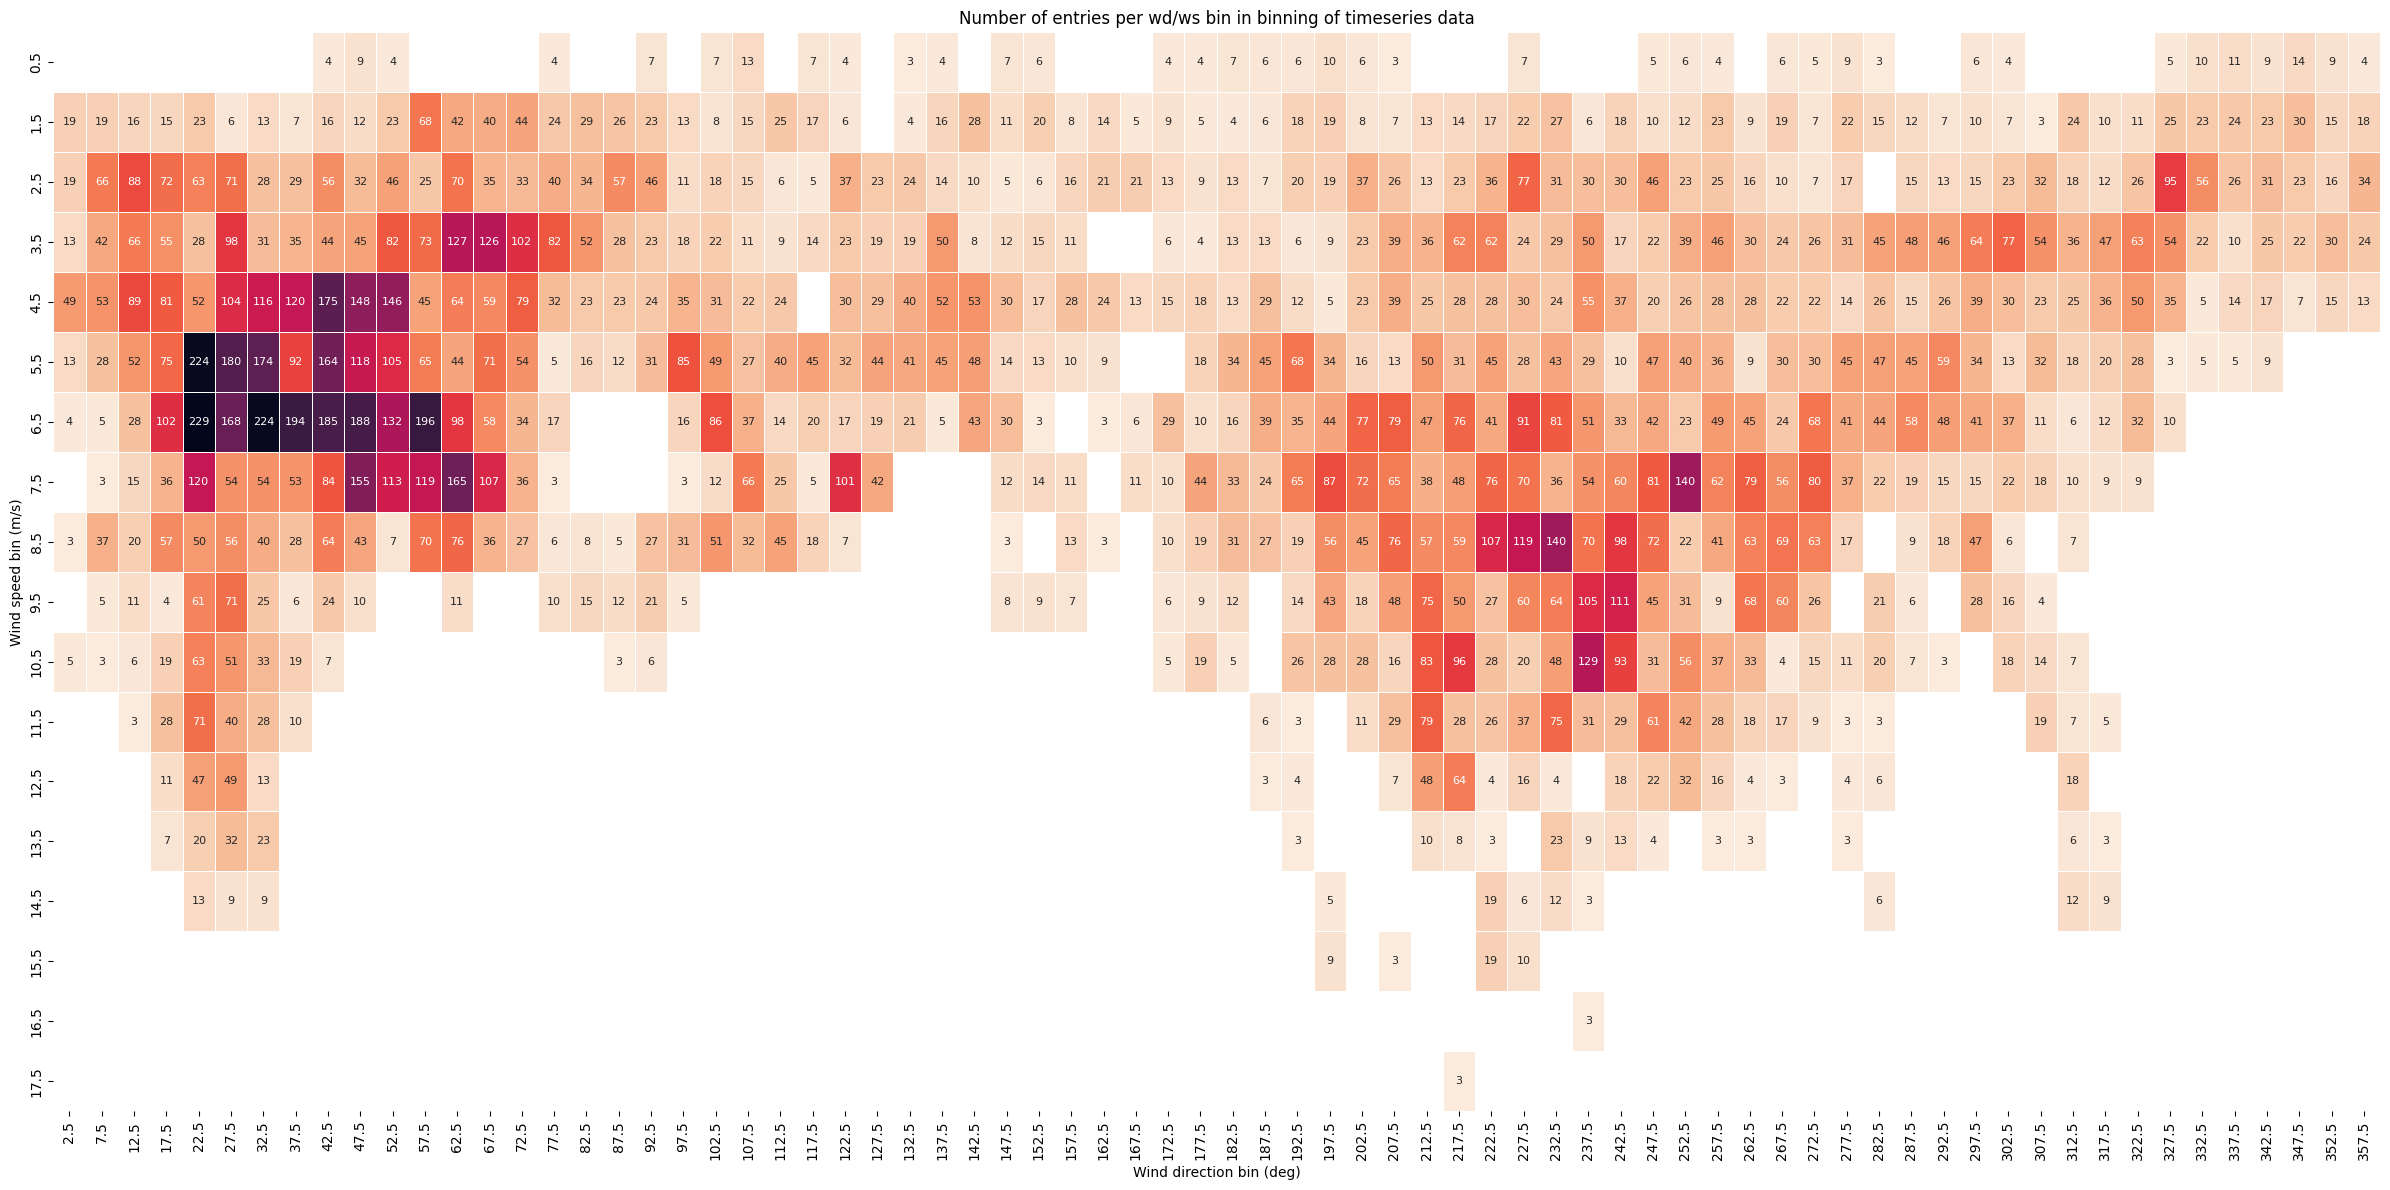

In [21]:
# # We start with the original timeseries, mapped onto the same time vector as the SCADA

# Copy NaNs over from the original SCADA to LES. This is beneficial because, for example,
# SCADA may have a lot of NaNs in particular seasons, weighing SCADA towards e.g. the
# summer. If we take the full LES timeseries without removing NaNs, we may be unfairly
# penalizing the LES while the underlying reason is a mismatch is seasonality.
df_list = dfm.df_mirror_timeseries_nans(df_list=[df_scada.copy(), df_les_raw_resampled.copy()])
df_les = df_list[1]

# We then turn the LES timeseries into a steady-state table by binning the LES data in
# wind direction and wind speed bins, and taking the average power in each bin as the steady-state power 
# for that bin. This is the LES-equivalent of a `df_fm_approx` table, which we can then use to remap the LES timeseries to
# have the same inflow conditions as SCADA, and then compare the remapped LES timeseries directly to SCADA.
df_approx_les_steadystate_table = bin_timeseries_to_grid(
    df_timeseries=df_les,
    wd_step=5.0,  # Preferably as low as possible, but with little data we may need to increase this to get enough samples in each bin
    wd_min=0.0,  # Cover entire wind rose
    wd_max=360.0,  # Cover entire wind rose
    ws_step=1.0,  # Preferably as low as possible, but with little data we may need to increase this to get enough samples in each bin
    ws_min=0.0,  # Take a very large range of wind speeds to cover all possible conditions
    ws_max=50.0,  # Take a very large range of wind speeds to cover all possible conditions
    N_min=3,  # Minimum number of samples within a bin for it to be considered valid and used to generate an approximate table entry with
    plot=True,  # Generate coverage plot: show how many samples we have in each wd/ws bin, and which bins are valid (i.e. have at least N_min samples)
)

# Use this steady-state table to produce a new LES timeseries with identical inflow as SCADA
df_les_timeseries_inflowremapped = ftools.interpolate_floris_from_df_approx(
    df=df_scada, df_approx=df_approx_les_steadystate_table, method="linear", verbose=False
)

# And finally, we can compare this inflow-remapped timeseries directly to SCADA.
# This may change the absolute AEP errors substantially, but likely will leave the relative wake loss percentages mostly intact.
print("\n")
table_absolute_aep_dict, table_wakeloss_aep_dict = compare_cumulative_production_and_relative_wake_loss(
    df_list=[df_scada, df_les_timeseries_inflowremapped, df_floris_timeseries],
    df_upstream=df_upstream,
    exclude_turbs=exclude_turbs,
    model_tags=["SCADA", "LES (inflow remapped to SCADA)", "FLORIS CC"],
    print_to_console=True,
)

# Extra: Plot wind-farm energy ratio
It generally is a good idea to check the energy ratios of the wind farm to ensure we are not making a mistake anywhere. We should roughly see agreement in where the largest wake dips occur. This is the case. We do not draw any further quantitative conclusions from these plots. And indeed, we see good qualitative agreement between the SCADA and the models.

Calculating energy ratios with bootstrapping (N=20).
This may take a couple seconds...


Text(0.5, 1.0, 'Energy Ratios for turbines [0, 1, 2, 3, 4, 5, 6]')

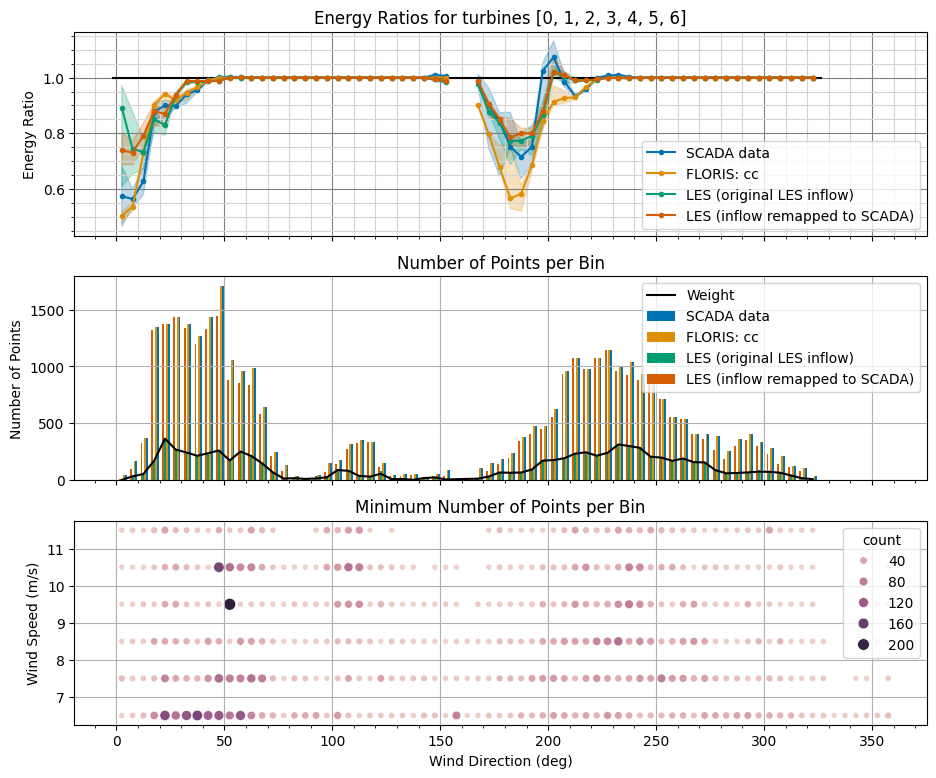

In [19]:
# Specify upstream turbines in same fashion as for the SCADA data
df_er_list = [df_scada, df_floris_timeseries, df_les_timeseries_raw, df_les_timeseries_inflowremapped]
df_er_list = [df.copy() for df in df_er_list]  # Independent copy
for df in df_er_list:
    df = dfm.set_pow_ref_by_upstream_turbines(df, df_upstream, exclude_turbs=exclude_turbs)

# Initialize energy ratio analysis class and perform common operations. E.g., let's look at turbine 4.
a_in = AnalysisInput(df_er_list,
    ["SCADA data", f"FLORIS: {wake_model}", "LES (original LES inflow)", "LES (inflow remapped to SCADA)"]
)

N = 20
print("Calculating energy ratios with bootstrapping (N={}).".format(N))
print("This may take a couple seconds...")
np.random.seed(0)
er_out = er.compute_energy_ratio(
    a_in,
    test_turbines=include_turbs,
    use_predefined_ref=True,
    use_predefined_wd=True,
    use_predefined_ws=True,
    wd_step=5.0,
    wd_bin_overlap_radius=0.0,
    ws_min=6.0,
    ws_max=12.0,
    N=N,
    percentiles=[5.0, 95.0],
)
ax = er_out.plot_energy_ratios(overlay_frequency=True)
ax[0].set_title(f"Energy Ratios for turbines {include_turbs}")